In [42]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as C
import latexify
import os
from flow_props import mass_evolution, vel_evolution
from stratified_box import StratifiedBox
from tqdm.notebook import tqdm
import itertools
import scipy.integrate
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table, initialize_cooling_constants, get_c_s

#os.environ["OPENBLAS_NUM_THREADS"] = "1"
# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")


# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25
H = 4

initialize_cooling_constants(5/3., mbar, 0.5882352941176471, 1.3157894736842106)
def strat_n(r):
    n0 = 10
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6


class TurbFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, vturb = 15, profile = 'MW', tcool = None, v0 = 0, cooling_factor = 1):
        print("This is initial height:", d0)
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.vturb = vturb * 1e3
        self.v0 = v0 * 1e3
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if tcool == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        else:
            self.Lambda_units = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s') / tcool
            self.tcool0 = tcool
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
        if self.vturb / 1000 > 30: f_A *= 2
        self.tgrow0 = cooling_factor* 35 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, vnot=1, f_KH = 3, alpha = 5/6., f_T = 1, verbose = 1, stop_mode = 'time', drag_bool = True):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y, vnot=vnot):
            """
            ODE system for cloud evolution.
            y = (z, v, m)
            """

            # Unpack state variables
            z, v, m = y

            # Position
            z_kpc = z / u.kpc.to("m")

            # Density and gravity
            rho_h = (
                self.profile_n(z_kpc)
                * mbar
                * u.g.to("kg")
                / (u.cm.to("m") ** 3)
            )
            g = -self.profile_g(z_kpc) * 1e-2  # cm/s^2 -> m/s^2

            # Cloud geometry
            C0 = 0.6  # drag coefficient
            rcl_pc = self.rcl(z_kpc)
            rcl_m = rcl_pc * u.pc.to("m")
            Across = np.pi * rcl_m**2

            # Kelvin–Helmholtz timescale factor
            r_pc_to_kpc = u.pc.to("kpc")
            v_tot = np.sqrt(v**2 + self.vturb**2)

            w_KH = (
                f_KH
                * np.sqrt(self.chi(z_kpc))
                * (self.r_cl0 * r_pc_to_kpc)
                / (t * v_tot / u.kpc.to("m"))
            )

            # Cooling time
            tcool_cl = (
                get_t_cool_n(
                    self.T_cl,
                    self.profile_n(z_kpc) * self.chi(z_kpc),
                )
                / u.Myr.to("s")
                / self.Lambda_units
            )

            # Velocity ratios
            vrat = 150.0 / min(abs(v_tot) / 1000.0, 150.0)

            tcoolrat = tcool_cl / self.tcool0
            mrat = m / (self.mass0 * u.Msun.to("kg"))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            v_abs = abs(v)
            v6_over_5 = v_abs * (v_abs**2) ** (1.0 / 5.0)

            v_combined = np.sqrt(
                self.vturb**(3/2) + v6_over_5**2 #/w_KH
            ) #if abs(v6_over_5) > self.vturb else self.vturb**(3/4)

            vrat2 = 150 / min(abs(v_combined), 150.0)

            # Growth timescales
            tgrow_turb = (
                self.chi(z_kpc)
                * self.r_cl0
                * u.pc.to("m")
                / self.vturb ** (3.0 / 4.0)
                * (
                    self.r_cl0
                    * u.pc.to("m")
                    / (tcool_cl * u.Myr.to("s"))
                ) ** (-1.0 / 4.0)
            )

            tgrow_infall = (
                w_KH
                * self.tgrow0
                * u.Myr.to("s")
                * vrat2
                * tcoolrat ** (1.0 / 4.0)
                * (mrat / rhorat) ** (1 - alpha)
            )

            tgrow = tgrow_infall


            

            


            def drag(self, rho_h, v, m):
                turb_drag = 0.5 * rho_h * Across * (100* self.vturb**2 + v**2 * C0)
                expr = g +turb_drag / m
                return expr
        
            if drag_bool: vterm = drag(self = self, rho_h=rho_h, v= v, m=m) - v / tgrow 
            else: vterm = g - v / tgrow

            dzdt = min(0,v)
            dvdt = min(0,vterm) if v > 0 else vterm
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), self.v0, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5 * 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'mass':
            def _odestop(t, y): 
                return y[2] / (self.mass0 * u.Msun.to('kg')) - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o, dense_output=True)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, alpha=5/6, f_T = 1.):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.pc.to('kpc')) /
            (self.d0 - z_kpc))


        tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') / self.Lambda_units
        vrat = np.ones_like(z_kpc)
        v_turb  = abs(self.vturb)/1000.
        v_infall = abs(v)/1000.


        v_tot = v_turb + (2/(1 + w_KH**2)) * v_infall
        vrat = 75 / np.minimum(abs(v_tot), 150.)

        # Result array:
        #vrat = np.where(
        #    w_KH > 1,
        #    150. / v_turb,
        #    150. / v_infall
        #)
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.Msun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow = self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)* (mrat**(1/3.))**0.75
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        #return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6)) - self.vturb / np.sqrt(0.6)
        return np.maximum(np.ones_like(z) * np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * (self.r_cl0 * u.pc.to('m'))**2 * 0.6)) -  self.vturb, 0)

        #return np.ones_like(z) * rho_h * self.vturb**2 * np.pi * self.r_cl0**2 

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to sim integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')


        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        #plt.yscale('log')
        plt.ylim(-10,100)
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")


def get_v_mass(r0, h, vturb, tcool=None, drag_bool = True):
    """
    Optimized version - only get final values without interpolation
    """

    if tcool is None: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb)
    else: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb, tcool=tcool)
    
    # FAST: Just get the solution without dense_output if you only need final values
    sol = cloud.integrate(1e3, stop_mode='mass',drag_bool = drag_bool)
    #cloud.plot_trajectory()
    
    # Get final values directly from the solution arrays
    t = sol.t
    z= sol.y[0, :]
    v = -sol.y[1, :]
    m = sol.y[2, :]
    m_initial = sol.y[2, 0]
    idx = np.argmax(v)
    
    return np.log10(m[idx]/m_initial), v[idx]/1000, t[idx]

def get_v_at_time(time, r0, h, vturb, tcool=None, drag_bool = True):
    """
    Optimized version - only get final values without interpolation
    """

    if tcool is None: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb)
    else: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb, tcool=tcool)
    
    # FAST: Just get the solution without dense_output if you only need final values
    sol = cloud.integrate(1e3, stop_mode='mass',drag_bool = drag_bool)
    #cloud.plot_trajectory()
    
    # Get final values directly from the solution arrays
    t = sol.t
    z= sol.y[0, :]
    v = -sol.y[1, :]
    m = sol.y[2, :]
    m_initial = sol.y[2, 0]
    idx = np.argmin(abs(np.array(t) - time))
    
    return np.log10(m[idx]/m_initial), v[idx]/1000


def get_v_mass_sim(rundir):
    sim = StratifiedBox(os.path.join(rundir, 'strat.in'), dir=rundir)
    mach = float(sim.reader.get('problem/turbulence', 'Mach_drive'))
    k_peak = float(sim.reader.get('problem/turbulence', 'kpeak'))
    
    Lymin, Lymax = float(sim.reader.get('parthenon/mesh', 'x2min')), float(sim.reader.get('parthenon/mesh', 'x2max'))
    Lxmin, Lxmax = float(sim.reader.get('parthenon/mesh', 'x1min')), float(sim.reader.get('parthenon/mesh', 'x1max'))
    Lzmin, Lzmax = float(sim.reader.get('parthenon/mesh', 'x3min')), float(sim.reader.get('parthenon/mesh', 'x3max'))
    
    L_drive = Lxmax - Lxmin
    V_box = (Lxmax - Lxmin) * (Lymax - Lymin) * (Lzmax - Lzmin)
    

    times, norm_mass, cgout, wgout, total = mass_evolution(rundir, gout=True)
    tvs, vel = vel_evolution(rundir)

    cs = get_c_s(1e6)
    velocity_cgs = sim.code_length_cgs / sim.code_time_cgs
    v_turb = cs * mach / velocity_cgs
    t_eddy = L_drive / v_turb
    
    
    # Find the value at target_teddy
    t_normalized = times / t_eddy
    target_idx = norm_mass > 3
    norm_mass = norm_mass[target_idx] - norm_mass[target_idx][0]
    timeseries = t_normalized[target_idx]

    mask = ~np.isnan(norm_mass)
    timeseries = timeseries[mask] *  sim.code_time_cgs / u.Myr.to('s')
    vel = vel[target_idx][mask]


    return norm_mass[np.argmax(vel)], vel[np.argmax(vel)]



this is tff:,  44.25286237443971
(3126,)
[False False False ...  True  True  True]
this is v:  43.59864394949709
1.0954772795665093


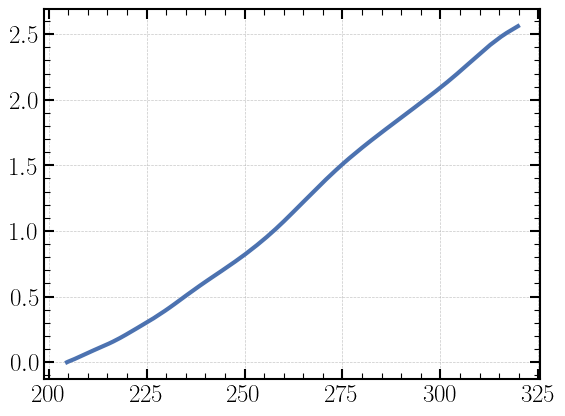

In [40]:
m, v = get_v_mass_sim('/viper/ptmp/ferhi/StratDisk/m0.5/r100/burnin')
times, mass, _, _, _ = mass_evolution('/viper/ptmp/ferhi/StratDisk/m0.1/r100/burnin')
print(np.shape(mass))
idx = mass > 3
print(idx)
plt.plot(times[idx], np.array(mass[idx]) - np.array(mass[idx][0]))
print("this is v: ", v)
print(m)

In [43]:
nm, nv, t = get_v_mass(r0=100, h=20, vturb=0, drag_bool=False)
mm, mv = get_v_at_time(t, 100, 20, 70, drag_bool=True)
print(nv)
print(mv)
print(t/u.Myr.to('s'))

This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 41.64268208735892
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 83.28536417471784
A termination event occurred.
62.118954840736066
-1.382605835963802e-11
31.11111


/tmp/ipykernel_2337878/1235265376.py:140: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2337878/1235265376.py:157: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150.0 / min(abs(v_tot) / 1000.0, 150.0)
/tmp/ipykernel_2337878/1235265376.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  vrat2 = 150 / min(abs(v_combined), 150.0)
/tmp/ipykernel_2337878/1235265376.py:174: RuntimeWarning: divide by zero encountered in scalar divide
  self.chi(z_kpc)


In [ ]:
import glob
import os
import re
import numpy as np
import itertools

# ------------------------------------------------------------
# 2. Make a list of the radius values (floats) from r* directory names
# ------------------------------------------------------------
simm = []
simv = []
turbcomm = []
turbcomv = []
noturbcomm = []
noturbcomv = []
tmaxnoturb = []


# ------------------------------------------------------------
# 1. Find all simulation directories
# ------------------------------------------------------------
base_pattern = "/viper/ptmp/ferhi/StratDisk/m0.*/r*"
sim_dirs = sorted(glob.glob(base_pattern))

if not sim_dirs:
    raise RuntimeError("No simulation directories found")

# ------------------------------------------------------------
# 2. Extract radius and Mach from directory names
# ------------------------------------------------------------
def extract_r(path):
    m = re.search(r"r([\d.]+)", path)
    return float(m.group(1)) if m else None

def extract_mach(path):
    m = re.search(r"m([\d.]+)", path)
    return float(m.group(1)) if m else None

radii = []
machs = []

for d in sim_dirs:
    try:

        dfull = os.path.join(d, 'burnin')
        m, vmax = get_v_mass_sim(dfull)
        simm.append(m)
        simv.append(vmax)
        r = extract_r(d)
        mach = extract_mach(d)

        if r is not None and mach is not None:
            radii.append(r)
            machs.append(mach)
    except Exception as e:
        print(f"Can't process run {d}: {e}")
        
radii = np.array(radii)
machs = np.array(machs)

if len(radii) == 0 or len(machs) == 0:
    raise RuntimeError("Failed to extract radii or Mach numbers")

# ------------------------------------------------------------
# 3. Determine parameter-space bounds
# ------------------------------------------------------------
r_min, r_max = radii.min(), 10**3#radii.max()
mach_min, mach_max = machs.min(), machs.max()

print(f"Radius range: {r_min:.3g} – {r_max:.3g} pc")
print(f"Mach range:   {mach_min:.3g} – {mach_max:.3g}")

# ------------------------------------------------------------
# 4. Generate log-spaced grids
# ------------------------------------------------------------
n_r = 30
n_m = 30

log_r = np.logspace(np.log10(r_min), np.log10(r_max), n_r)
log_mach = np.logspace(np.log10(mach_min), np.log10(mach_max), n_m)






combs = list(itertools.product(log_r,log_mach))


# Computations
for rcl, mach in tqdm(combs):
    nm, nv, _ = get_v_mass_at_tff(rcl, h=20, vturb = mach * 150 )
    ntnm, ntnv, _ = get_v_mass_at_tff(rcl, h=20, vturb = mach * 150, drag_bool=False)
    turbcomm.append(nm)
    turbcomv.append(nv)
    noturbcomm.append(ntnm)
    noturbcomv.append(ntnv)
    _, _, tmax = get_v_mass_at_tff(rcl, h=20, vturb=0, drag_bool=False)
    tmaxnoturb.append(tmax)


    

this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
Can't process run /viper/ptmp/ferhi/StratDisk/m0.1/r1e3: index 0 is out of bounds for axis 0 with size 0
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
Can't process run /viper/ptmp/ferhi/StratDisk/m0.5/r100_bigger: too many indices for array: array is 1-dimensional, but 2 were indexed
Radius range: 0.1 – 1e+03 pc
Mach range:   0.1 – 0.5


  0%|          | 0/900 [00:00<?, ?it/s]

This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtg

/tmp/ipykernel_2337878/515562948.py:140: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH


A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0

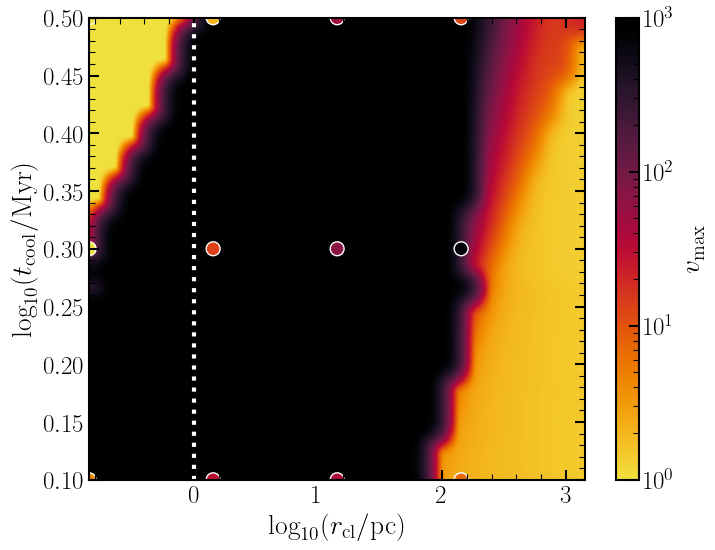

In [17]:
import cmasher as cmr
from matplotlib.colors import LogNorm
vmin = 1
vmax = 1e3
cmap = cmr.ember_r
norm = LogNorm(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(pow(10, np.array(turbcomm)), (len(log_r), len(log_mach))).copy().T
z_mm = mrat
x_m = np.log10(log_r/0.7)
y_m = log_mach
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_mm, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
vals = np.clip(pow(10, np.array(simm)), vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(radii)/0.7), machs,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)
plt.show()

[np.float64(3.2189176101644104), np.float64(3.1491515313051317), np.float64(9.788507482702615), np.float64(65.17354577295515), np.float64(-1.9312363968536298e-20), np.float64(3.669443823477149), np.float64(7.865785840836561), np.float64(34.73541347595533), np.float64(12.005562781268509), np.float64(7.051530263029236), np.float64(1.8110226656544843), np.float64(43.59864394949709)]


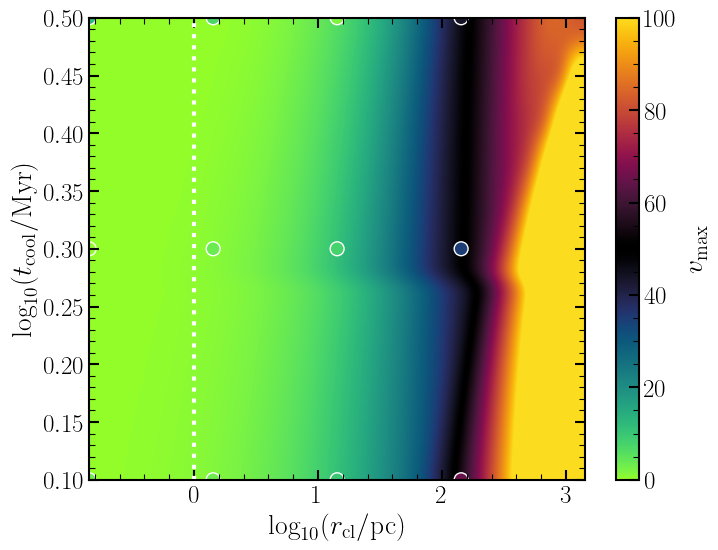

In [25]:
import cmasher as cmr
from matplotlib.colors import LogNorm
vmin = 0
vmax = 100
cmap = cmr.wildfire
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(turbcomv, (len(log_r), len(log_mach))).copy().T
z_m = mrat
x_m = np.log10(log_r/0.7)
y_m = log_mach
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_m, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
print(simv)
vals = np.clip(simv, vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(radii)/0.7), machs,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)
plt.show()

[8, 9, 10, 11]
[12.00556278  7.05153026  1.81102267 43.59864395]
4


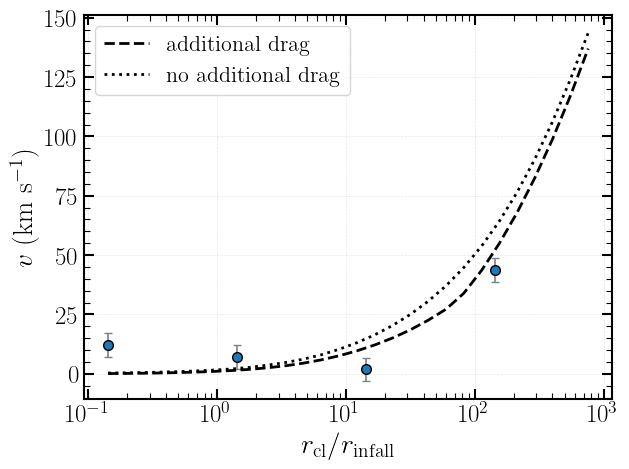

In [33]:
# ------------------------------------------------------------
# Find closest simulation for each log_r grid point
# ------------------------------------------------------------
indices = [i for i,v in enumerate(machs) if v==0.5]#np.abs(target[:, None] - radii).argmin(axis=1)  # axis=1, not axis=0
print(indices)

# Selected values
selected_paths = [sim_dirs[i] for i in indices]
vs = np.array([simv[i] for i in indices])
print(vs)
rs = np.array([radii[i] for i in indices])
print(len(selected_paths))

# ---------------------
# SCATTER WITH ERRORBARS
# ---------------------
plt.errorbar(
    rs/0.7, vs,
    yerr=5,              # ±5
    fmt='o',             # circular marker
    color='tab:blue',    # default color
    ecolor='gray',       # error bar color
    elinewidth=1.2,
    capsize=3,
    markersize=7,
    markeredgecolor='black'
)

# ---------------------
# FIXED MACH SLICE
# ---------------------
# ---------------------
# FIXED MACH SLICE
# ---------------------
target_mach = np.log10(0.5)  # 10^0.5
idx_mach = np.argmin(np.abs(log_mach - target_mach))

# Extract slices at fixed Mach by filtering the combinations
# For each radius index, get the corresponding entry at idx_mach
z_slice = []
z_nodrag = []
for i in range(n_r):
    # The flat index for (i, idx_mach) in the product order
    flat_idx = i * n_m + idx_mach
    z_slice.append(turbcomv[flat_idx])
    z_nodrag.append(noturbcomv[flat_idx])

z_slice = np.array(z_slice)
z_nodrag = np.array(z_nodrag)
x_vals = log_r / 0.7  # radius values

# ---------------------
# SLICED LINE (BLACK + DASHED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_slice[:-2],
    color='black',
    linestyle='--',
    linewidth=2,
    label=r"additional drag"
)

# ---------------------
# SLICED NO DRAG (BLACK + DOTTED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_nodrag[:-2],
    color='black',
    linestyle=':',
    linewidth=2,
    label=r"no additional drag"
)

# ---------------------
# AXES & LABELS
# ---------------------
plt.xscale('log')
plt.xlabel(r'$r_{\rm cl} / r_{\rm infall}$')
plt.ylabel(r'$v$ (km s$^{-1}$)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('v_r_plot.png')

In [ ]:
import glob
import os
import re
import numpy as np
import itertools

# ------------------------------------------------------------
# 2. Make a list of the radius values (floats) from r* directory names
# ------------------------------------------------------------
simm = []
simv = []
turbcomm = []
turbcomv = []
noturbcomm = []
noturbcomv = []
tmaxnoturb = []


# ------------------------------------------------------------
# 1. Find all simulation directories
# ------------------------------------------------------------
base_pattern = "/viper/ptmp/ferhi/StratDisk/m0.*/r*"
sim_dirs = sorted(glob.glob(base_pattern))

if not sim_dirs:
    raise RuntimeError("No simulation directories found")

# ------------------------------------------------------------
# 2. Extract radius and Mach from directory names
# ------------------------------------------------------------
def extract_r(path):
    m = re.search(r"r([\d.]+)", path)
    return float(m.group(1)) if m else None

def extract_mach(path):
    m = re.search(r"m([\d.]+)", path)
    return float(m.group(1)) if m else None

radii = []
machs = []

for d in sim_dirs:
    try:

        dfull = os.path.join(d, 'burnin')
        m, vmax = get_v_mass_sim(dfull)
        simm.append(m)
        simv.append(vmax)
        r = extract_r(d)
        mach = extract_mach(d)

        if r is not None and mach is not None:
            radii.append(r)
            machs.append(mach)
    except Exception as e:
        print(f"Can't process run {d}: {e}")
        
radii = np.array(radii)
machs = np.array(machs)

if len(radii) == 0 or len(machs) == 0:
    raise RuntimeError("Failed to extract radii or Mach numbers")

# ------------------------------------------------------------
# 3. Determine parameter-space bounds
# ------------------------------------------------------------
r_min, r_max = radii.min(), 10**3#radii.max()
mach_min, mach_max = machs.min(), machs.max()

print(f"Radius range: {r_min:.3g} – {r_max:.3g} pc")
print(f"Mach range:   {mach_min:.3g} – {mach_max:.3g}")

# ------------------------------------------------------------
# 4. Generate log-spaced grids
# ------------------------------------------------------------
n_r = 30
n_m = 30

log_r = np.logspace(np.log10(r_min), np.log10(r_max), n_r)
log_mach = np.logspace(np.log10(mach_min), np.log10(mach_max), n_m)






combs = list(itertools.product(log_r,log_mach))


# Computations
for rcl, mach in tqdm(combs):
    ntnm, ntnv, tmax = get_v_mass(rcl, h=20, vturb=0, drag_bool=False)
    tmaxnoturb.append(tmax)
    nm, nv= get_v_at_time(tmax, rcl, h=20, vturb = mach * 150, drag_bool=True )
    turbcomm.append(nm)
    turbcomv.append(nv)
    noturbcomm.append(ntnm)
    noturbcomv.append(ntnv)


this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
Can't process run /viper/ptmp/ferhi/StratDisk/m0.1/r1e3: index 0 is out of bounds for axis 0 with size 0
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
this is tff:,  44.25286237443971
Can't process run /viper/ptmp/ferhi/StratDisk/m0.5/r100_bigger: too many indices for array: array is 1-dimensional, but 2 were indexed
Radius range: 0.1 – 1e+03 pc
Mach range:   0.1 – 0.5


  0%|          | 0/900 [00:00<?, ?it/s]

This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtg

/tmp/ipykernel_2337878/1235265376.py:140: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2337878/1235265376.py:157: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150.0 / min(abs(v_tot) / 1000.0, 150.0)
/tmp/ipykernel_2337878/1235265376.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  vrat2 = 150 / min(abs(v_combined), 150.0)
/tmp/ipykernel_2337878/1235265376.py:174: RuntimeWarning: divide by zero encountered in scalar divide
  self.chi(z_kpc)


This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtgrow0: 0.23417401029485835
A termination event occurred.
This is initial height: 20
This is Tcool0: 0.0006061610372462417
This is gtg

In [ ]:
# ------------------------------------------------------------
# Find closest simulation for each log_r grid point
# ------------------------------------------------------------
indices = [i for i,v in enumerate(machs) if v==0.5]#np.abs(target[:, None] - radii).argmin(axis=1)  # axis=1, not axis=0
print(indices)

# Selected values
selected_paths = [sim_dirs[i] for i in indices]
vs = np.array([simv[i] for i in indices])
print(vs)
rs = np.array([radii[i] for i in indices])
print(len(selected_paths))

# ---------------------
# SCATTER WITH ERRORBARS
# ---------------------
plt.errorbar(
    rs/0.7, vs,
    yerr=5,              # ±5
    fmt='o',             # circular marker
    color='tab:blue',    # default color
    ecolor='gray',       # error bar color
    elinewidth=1.2,
    capsize=3,
    markersize=7,
    markeredgecolor='black'
)

# ---------------------
# FIXED MACH SLICE
# ---------------------
# ---------------------
# FIXED MACH SLICE
# ---------------------
target_mach = np.log10(0.5)  # 10^0.5
idx_mach = np.argmin(np.abs(log_mach - target_mach))

# Extract slices at fixed Mach by filtering the combinations
# For each radius index, get the corresponding entry at idx_mach
z_slice = []
z_nodrag = []
for i in range(n_r):
    # The flat index for (i, idx_mach) in the product order
    flat_idx = i * n_m + idx_mach
    z_slice.append(turbcomv[flat_idx])
    z_nodrag.append(noturbcomv[flat_idx])

z_slice = np.array(z_slice)
z_nodrag = np.array(z_nodrag)
x_vals = log_r / 0.7  # radius values

# ---------------------
# SLICED LINE (BLACK + DASHED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_slice[:-2],
    color='black',
    linestyle='--',
    linewidth=2,
    label=r"additional drag"
)

# ---------------------
# SLICED NO DRAG (BLACK + DOTTED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_nodrag[:-2],
    color='black',
    linestyle=':',
    linewidth=2,
    label=r"no additional drag"
)

# ---------------------
# AXES & LABELS
# ---------------------
plt.xscale('log')
plt.xlabel(r'$r_{\rm cl} / r_{\rm infall}$')
plt.ylabel(r'$v$ (km s$^{-1}$)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('v_r_plot.png')

In [7]:
def get_tgrow_over_tcc_at_vmax(r0,h,vturb, tcool):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb, tcool=tcool)
    

    sol = cloud.integrate(0.01, stop_mode='height')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)
    
    
    tgrow_vmax = cloud.vTgrow(z[idx_vmax], v[idx_vmax], m[idx_vmax]) * 1e2 / cloud.profile_g(z[idx_vmax])
    tcc_vmax = np.sqrt(cloud.profile_T(z[idx_vmax])/1e4)*r0 * u.pc.to('m')/v[idx_vmax]

    return tgrow_vmax/tcc_vmax, v[idx_vmax]

In [8]:
combs = list(itertools.product(logspace_r, logspace_cooling))
fclst = []
vmlst = []
for rcl, tcool in tqdm(combs):
    tt, vm = get_tgrow_over_tcc_at_vmax(rcl,3, vturb=10, tcool=tcool)
    fclst.append(tt)
    vmlst.append(vm)

  0%|          | 0/900 [00:00<?, ?it/s]

/u/ferhi/own_package/plots/infalling_clouds.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.


/u/ferhi/own_package/plots/infalling_clouds.py:127: RuntimeWarning: invalid value encountered in scalar power
  tgrow = self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)


A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A terminat

[np.float64(-9.104004020118646), np.float64(-8.077896868934086), np.float64(-8.95363701235696), np.float64(-8.487309256727494), np.float64(70.18319058534667), np.float64(53.017608967658326), np.float64(68.91980117742447), np.float64(50.81772738228729), np.float64(51.674222940469974), np.float64(46.22863371570714), np.float64(-0.9539152567749662), np.float64(-0.9539152567749662), np.float64(-0.3744886242081043), np.float64(0.253089292845712), np.float64(0.16709918902058638), np.float64(0.03905185380291258), np.float64(-0.3744886242081043), np.float64(5.833244752358859), np.float64(7.598631000888641), np.float64(3.8705394361703225), np.float64(5.150109678539303), np.float64(7.598631000888641), np.float64(3.7866493148587614), np.float64(3.4995029414789403), np.float64(5.150109678539303)]


(-6.0, -1.0)

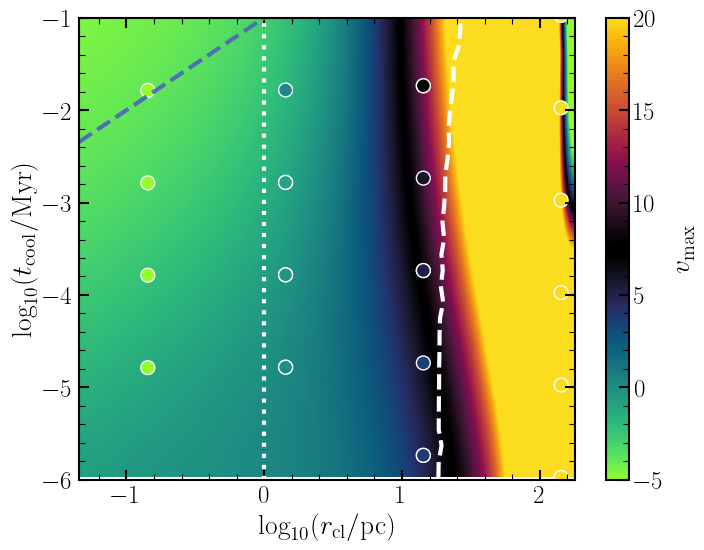

In [9]:
vmin = -5
vmax = 20
cmap = cmr.wildfire
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(comv, (len(logspace_r), len(logspace_cooling))).copy().T
z_m = mrat
x_m = np.log10(logspace_r/0.7)
y_m = np.log10(logspace_cooling)
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_m, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
print(simv)
vals = np.clip(simv, vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(rclvals)/0.7), digits,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)

trat_arr = np.reshape(fclst,(len(logspace_r),len(logspace_cooling))).copy().T
plt.contour(np.log10(logspace_r/0.7),np.log10(logspace_cooling),trat_arr,levels=[4],colors='white',linestyles='dashed')
plt.plot(np.log10(logspace_r/0.7), np.log10(logspace_r/0.7) - 1, linestyle= "dashed")
plt.ylim(bottom=-6, top=-1)

In [12]:
# Computations
cv_nodrag = []
cm_nodrag = []
for rcl, tcool in tqdm(combs):
    nm, nv = get_v_mass_at_tff(rcl, 3, vturb = 15, tcool=tcool, drag_bool=False)
    cv_nodrag.append(nv)
    cm_nodrag.append(nm)
vz_nodrag = np.reshape(cv_nodrag, (len(logspace_r), len(logspace_cooling))).copy().T
mz_nodrag = np.reshape(cm_nodrag, (len(logspace_r), len(logspace_cooling))).copy().T

  0%|          | 0/900 [00:00<?, ?it/s]

/u/ferhi/own_package/plots/infalling_clouds.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/u/ferhi/own_package/plots/infalling_clouds.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150. / min(abs(v)/1000, 150.)


The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver

5


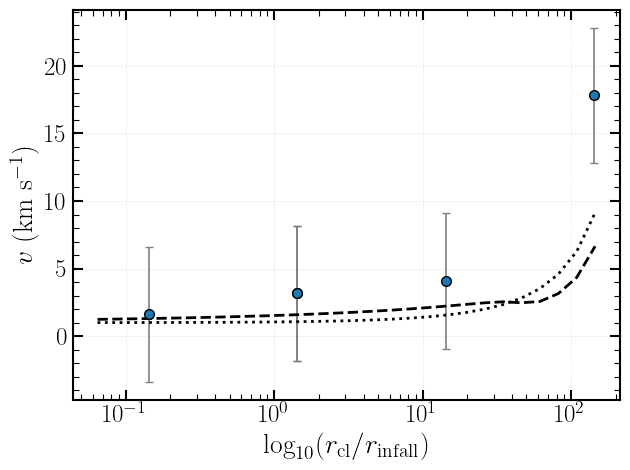

In [15]:
indices = [i for i, v in enumerate(digits) if -3 < v < -2]

# Selected values
selected_paths = [t1e_paths[i] for i in indices]
ms = np.array([simm[i] for i in indices])
rs = np.array([rclvals[i] for i in indices])

print(len(selected_paths))

# ---------------------
# SCATTER WITH ERRORBARS
# ---------------------
plt.errorbar(
    rs/0.7, ms,
    yerr=5,              # ±5
    fmt='o',             # circular marker
    color='tab:blue',    # default color
    ecolor='gray',       # error bar color
    elinewidth=1.2,
    capsize=3,
    markersize=7,
    markeredgecolor='black'
)

# ---------------------
# FIXED COOLING SLICE: y = 10^-2
# ---------------------
target_log_y = -2
idx_y = np.argmin(np.abs(y_m - target_log_y))

z_slice = z_mm[idx_y, :]   # 1D z values at that cooling
x_slice = x_m             # log10(r / 0.7)

# Convert x back to linear radius (divide by 0.7 like your scatter)
x_vals = 10**x_slice / 0.7
z_nodrag = mz_nodrag[idx_y, :]

# ---------------------
# SLICED LINE (BLACK + DASHED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_slice[:-2],
    color='black',
    linestyle='--',
    linewidth=2,
    label=r"$t_{\rm cool}=10^{-2}$ slice"
)
# ---------------------
# SLICED NO DRAG (BLACK + DOTTED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_nodrag[:-2],
    color='black',
    linestyle=':',
    linewidth=2,
    label=r"$t_{\rm cool}=10^{-2}$ slice"
)
# ---------------------
# AXES & LABELS
# ---------------------
plt.xscale('log')
plt.xlabel(r'$\log_{10}(r_{\rm cl} / r_{\rm infall})$')
plt.ylabel(r'$v$ (km s$^{-1}$)')
plt.grid(alpha=0.3)
plt.tight_layout()


PLOTS FOR TURB VS NO TURB 